Thermalization query filters:
  Phase_Separation_Status: Not_Separated
  Nsteps: 200000
  dt: 0.002
  Ensemble: ['NVT']
  Clone_Run_ID: None


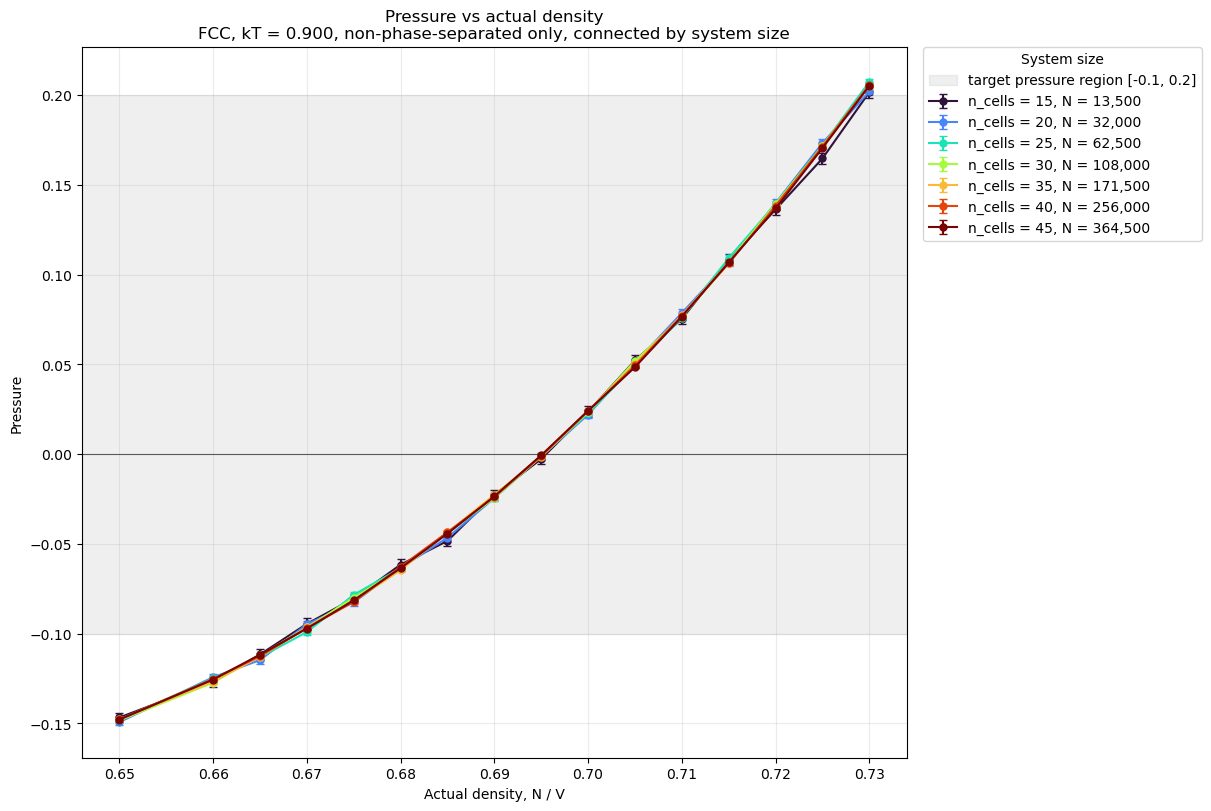

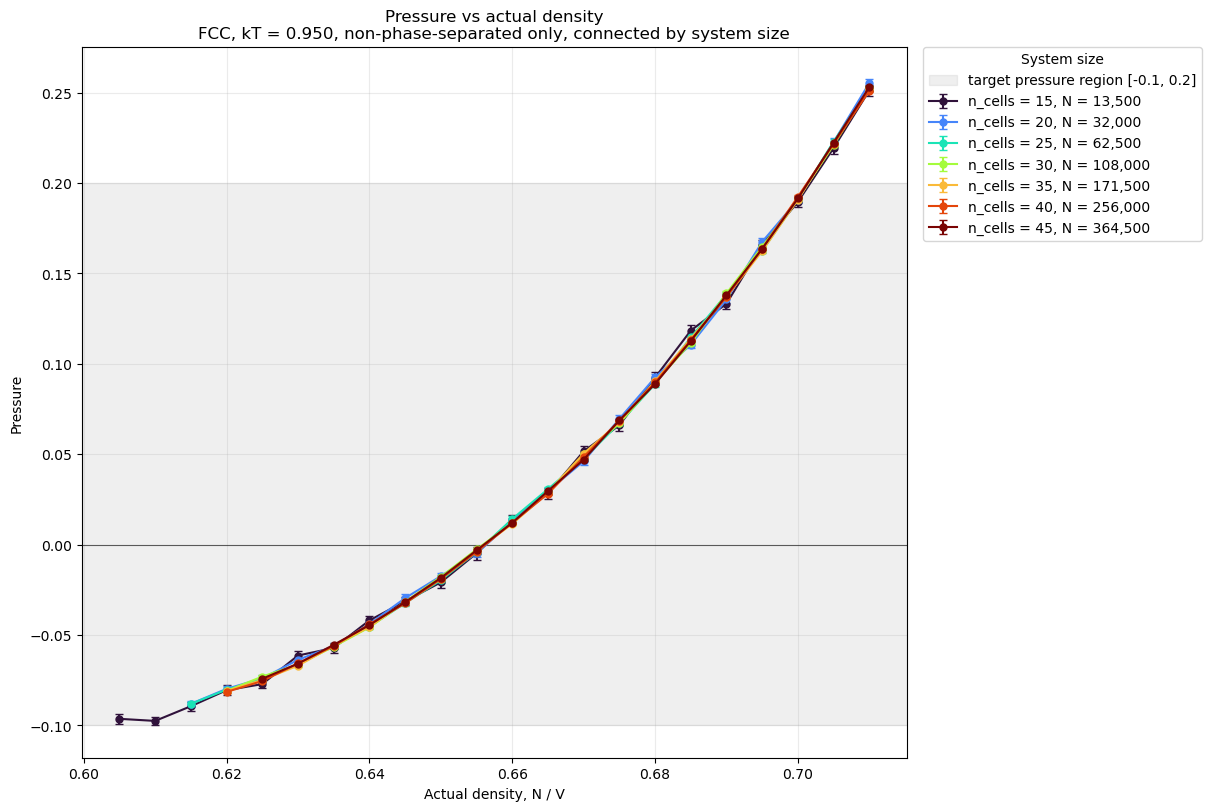

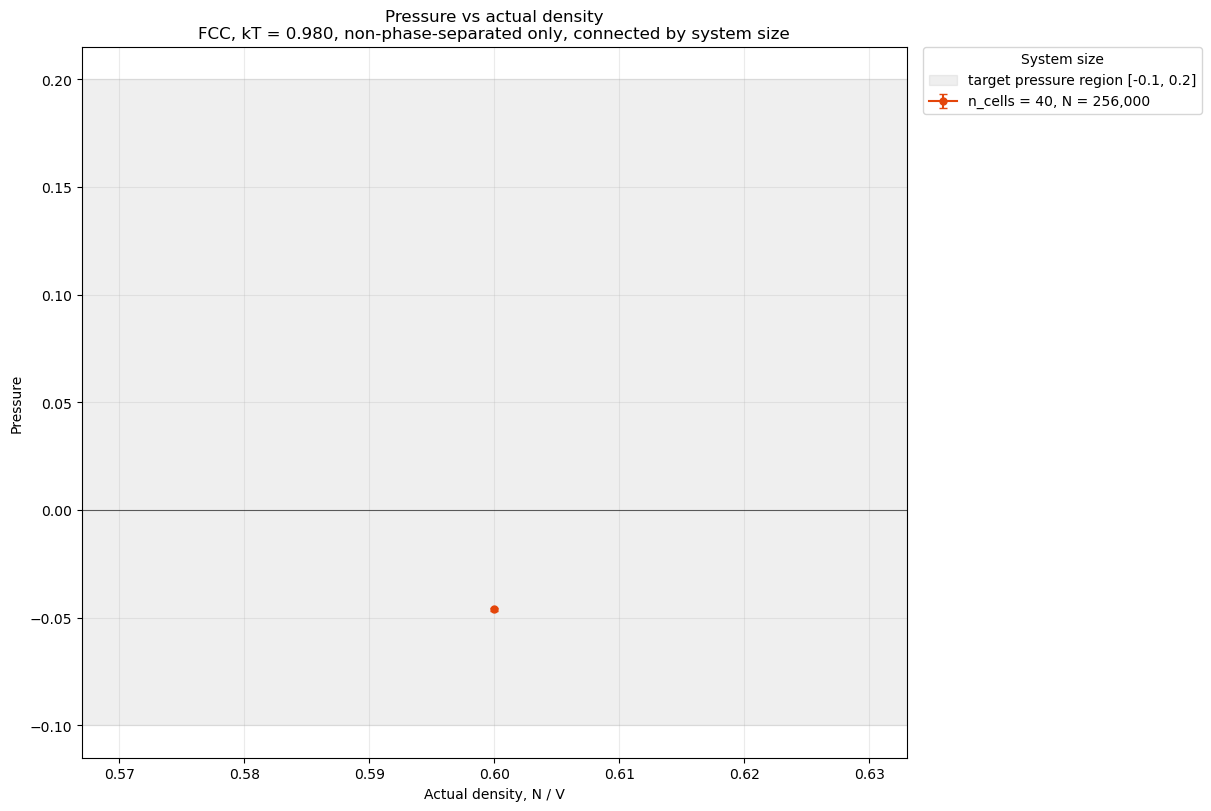

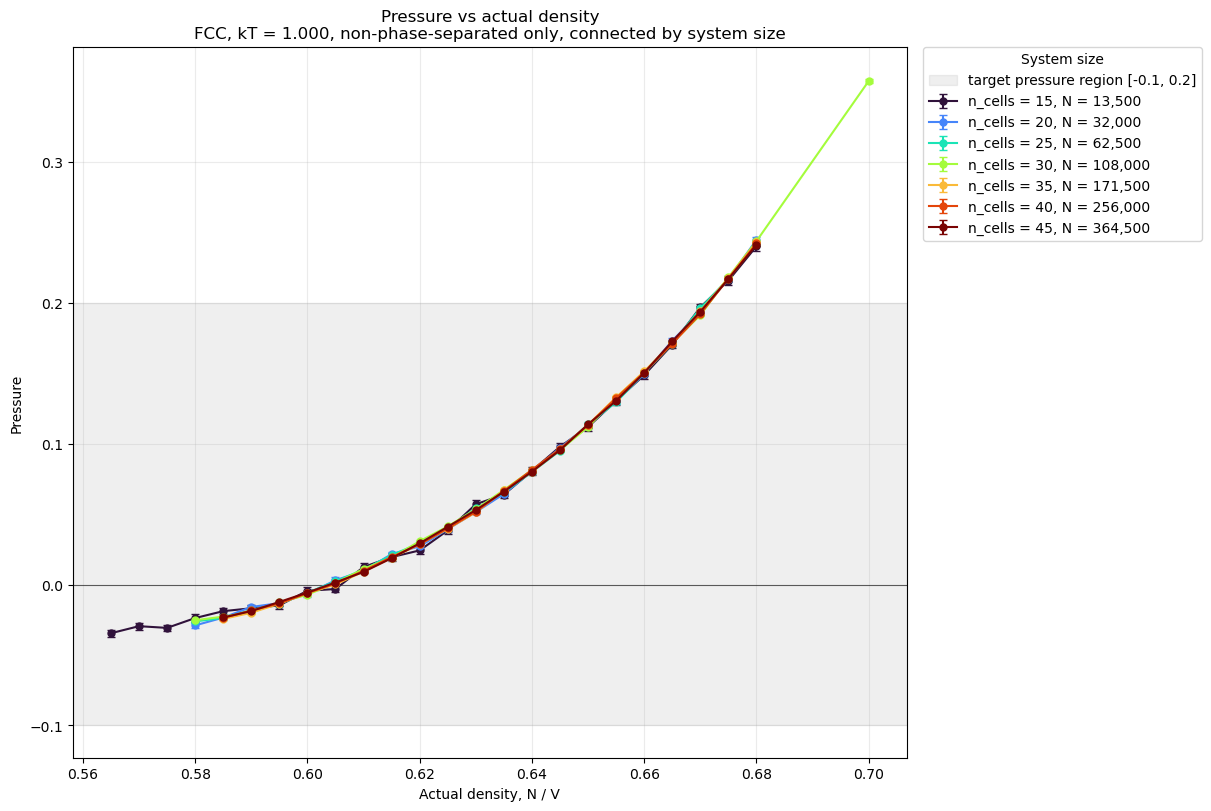

,Run_ID,N_Cells,N_Particles,Therm_kT,Actual_Density,Pressure_Mean,Pressure_SEM,PE_Per_Particle_Mean,PE_Per_Particle_SEM,Nsteps,Therm_Seed,Clone_Run_ID
0,20260917190822,15,13500,0.9,0.650,-0.146650,0.002392,-4.146558,0.000661,200000,1,None
1,20260917191018,15,13500,0.9,0.660,-0.126864,0.002592,-4.205507,0.000695,200000,1,None
2,20260917212450,15,13500,0.9,0.665,-0.111551,0.003082,-4.235116,0.000708,200000,1,None
3,20260917190939,15,13500,0.9,0.670,-0.094486,0.003096,-4.264491,0.000633,200000,1,None
4,20260917212412,15,13500,0.9,0.675,-0.080368,0.002661,-4.294923,0.000644,200000,1,None
...,...,...,...,...,...,...,...,...,...,...,...,...
393,20260918015417,45,364500,1.0,0.660,0.150322,0.000543,-4.136658,0.000132,200000,1,None
394,20260918232346,45,364500,1.0,0.665,0.172667,0.000602,-4.166541,0.000141,200000,1,None
395,20260918015941,45,364500,1.0,0.670,0.193776,0.000648,-4.196808,0.000152,200000,1,None
396,20260918232914,45,364500,1.0,0.675,0.216987,0.000510,-4.227253,0.000130,200000,1,None


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from md_Helpers import (
    ProjectPaths,
    SQLiteRunDatabase,
)


# ============================================================
# Configuration
# ============================================================

paths = ProjectPaths()
database = SQLiteRunDatabase(paths.database)
database.initialize()

# EOS states must be homogeneous.
phase_status = "Not_Separated"

# Set to None to include every available value.
# Use lists when selecting multiple discrete values.
selected_n_cells = None
selected_temperatures = None
selected_nsteps = 200_000
selected_dt = 0.002
selected_seeds = None
selected_ensembles = ["NVT"]

# Optional additional protocol filters.
selected_lj_modes = None
selected_lj_r_cut = None
selected_lj_r_on = None

# Cloned/rescaled runs collect pressure while their density is changing.
# Keep False for fixed-density EOS data.
include_rescaled_clones = False

# Highlight the pressure region relevant to the cavitation study.
highlight_pressure_region = True
pressure_min = -0.1
pressure_max = 0.2

# Optional plot limits. Use None for automatic limits.
density_limits = None
pressure_limits = None

figure_size = (12, 8)
errorbar_capsize = 3
line_width = 1.5
marker_size = 5


# ============================================================
# Query completed homogeneous thermalizations
# ============================================================

query_filters = {
    "Phase_Separation_Status": phase_status,
}

if selected_n_cells is not None:
    query_filters["N_Cells"] = selected_n_cells

if selected_temperatures is not None:
    query_filters["Therm_kT"] = selected_temperatures

if selected_nsteps is not None:
    query_filters["Nsteps"] = selected_nsteps

if selected_dt is not None:
    query_filters["dt"] = selected_dt

if selected_seeds is not None:
    query_filters["Therm_Seed"] = selected_seeds

if selected_ensembles is not None:
    query_filters["Ensemble"] = selected_ensembles

if selected_lj_modes is not None:
    query_filters["LJ_Mode"] = selected_lj_modes

if selected_lj_r_cut is not None:
    query_filters["LJ_r_cut"] = selected_lj_r_cut

if selected_lj_r_on is not None:
    query_filters["LJ_r_on"] = selected_lj_r_on

if not include_rescaled_clones:
    query_filters["Clone_Run_ID"] = None

print("Thermalization query filters:")
for name, value in query_filters.items():
    print(f"  {name}: {value}")

rows = database.query_thermalizations(**query_filters)


eos_states = pd.DataFrame(rows)

if eos_states.empty:
    raise RuntimeError(
        "No thermalization states matched the EOS query. "
        f"Filters: {query_filters}"
    )

# ============================================================
# Clean and validate EOS columns
# ============================================================

required_columns = [
    "Run_ID",
    "N_Cells",
    "Therm_kT",
    "Density_End",
    "Pressure_Mean",
    "Pressure_SEM",
    "Phase_Separation_Status",
]

missing_columns = [
    column
    for column in required_columns
    if column not in eos_states.columns
]

if missing_columns:
    raise KeyError(
        f"Thermalization query is missing columns: "
        f"{missing_columns}"
    )

numeric_columns = [
    "N_Cells",
    "Therm_kT",
    "Density_End",
    "Pressure_Mean",
    "Pressure_SEM",
]

for column in numeric_columns:
    eos_states[column] = pd.to_numeric(
        eos_states[column],
        errors="coerce",
    )

eos_states = eos_states.loc[
    np.isfinite(eos_states["N_Cells"])
    & np.isfinite(eos_states["Therm_kT"])
    & np.isfinite(eos_states["Density_End"])
    & np.isfinite(eos_states["Pressure_Mean"])
].copy()

if eos_states.empty:
    raise RuntimeError(
        "The matching thermalization states contain no finite "
        "density and pressure results."
    )

eos_states["N_Cells"] = eos_states["N_Cells"].astype(int)
eos_states["N_Particles"] = 4 * eos_states["N_Cells"] ** 3
eos_states["Actual_Density"] = eos_states["Density_End"]

eos_states = (
    eos_states
    .sort_values(
        ["N_Cells", "Therm_kT", "Actual_Density", "Run_ID"]
    )
    .reset_index(drop=True)
)


# ============================================================
# Report duplicate interpolation coordinates
# ============================================================

coordinate_columns = [
    "N_Cells",
    "Therm_kT",
    "Actual_Density",
]

duplicate_coordinates = eos_states.loc[
    eos_states.duplicated(
        subset=coordinate_columns,
        keep=False,
    )
].copy()

if not duplicate_coordinates.empty:
    print(
        "Warning: multiple runs share the same "
        "(N_Cells, Therm_kT, Actual_Density)."
    )
    print(
        "These should be reviewed before constructing "
        "the interpolation table."
    )

    display(
        duplicate_coordinates[
            [
                "Run_ID",
                "N_Cells",
                "Therm_kT",
                "Actual_Density",
                "Pressure_Mean",
                "Pressure_SEM",
                "Nsteps",
                "Therm_Seed",
                "Clone_Run_ID",
            ]
        ]
    )




# ============================================================
# Use one consistent N_Cells color scale
# ============================================================

all_n_cells = np.sort(
    eos_states["N_Cells"].unique()
)

n_cells_colormap = mpl.colormaps["turbo"]

n_cells_colors = {
    int(n_cells): n_cells_colormap(
        index / max(len(all_n_cells) - 1, 1)
    )
    for index, n_cells in enumerate(all_n_cells)
}


# ============================================================
# Plot one EOS figure for each temperature
# ============================================================

figures = {}

for temperature, temperature_data in eos_states.groupby(
    "Therm_kT",
    sort=True,
):
    temperature_data = temperature_data.copy()

    figure, axis = plt.subplots(
        figsize=figure_size,
        constrained_layout=True,
    )

    if highlight_pressure_region:
        axis.axhspan(
            pressure_min,
            pressure_max,
            color="gray",
            alpha=0.12,
            label=(
                f"target pressure region "
                f"[{pressure_min:g}, {pressure_max:g}]"
            ),
        )

    for n_cells, size_data in temperature_data.groupby(
        "N_Cells",
        sort=True,
    ):
        size_data = (
            size_data
            .sort_values("Actual_Density")
            .reset_index(drop=True)
        )

        n_cells = int(n_cells)
        n_particles = 4 * n_cells**3
        color = n_cells_colors[n_cells]

        pressure_sem = size_data[
            "Pressure_SEM"
        ].to_numpy(dtype=float)

        # Replace unavailable uncertainties with zero for plotting only.
        pressure_sem = np.where(
            np.isfinite(pressure_sem),
            pressure_sem,
            0.0,
        )

        axis.errorbar(
            size_data["Actual_Density"],
            size_data["Pressure_Mean"],
            yerr=pressure_sem,
            marker="o",
            markersize=marker_size,
            linewidth=line_width,
            capsize=errorbar_capsize,
            color=color,
            label=(
                f"n_cells = {n_cells}, "
                f"N = {n_particles:,}"
            ),
        )

    axis.axhline(
        0.0,
        color="black",
        linewidth=0.8,
        alpha=0.6,
    )

    axis.set_title(
        "Pressure vs actual density\n"
        f"FCC, kT = {float(temperature):.3f}, "
        "non-phase-separated only, connected by system size"
    )

    axis.set_xlabel("Actual density, N / V")
    axis.set_ylabel("Pressure")
    axis.grid(True, alpha=0.25)

    if density_limits is not None:
        axis.set_xlim(*density_limits)

    if pressure_limits is not None:
        axis.set_ylim(*pressure_limits)

    axis.legend(
        title="System size",
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        borderaxespad=0.0,
    )

    figures[float(temperature)] = figure
    plt.show()


# ============================================================
# Display the exact points used in the plots
# ============================================================

eos_plot_points = eos_states[
    [
        "Run_ID",
        "N_Cells",
        "N_Particles",
        "Therm_kT",
        "Actual_Density",
        "Pressure_Mean",
        "Pressure_SEM",
        "PE_Per_Particle_Mean",
        "PE_Per_Particle_SEM",
        "Nsteps",
        "Therm_Seed",
        "Clone_Run_ID",
    ]
].copy()

display(eos_plot_points)

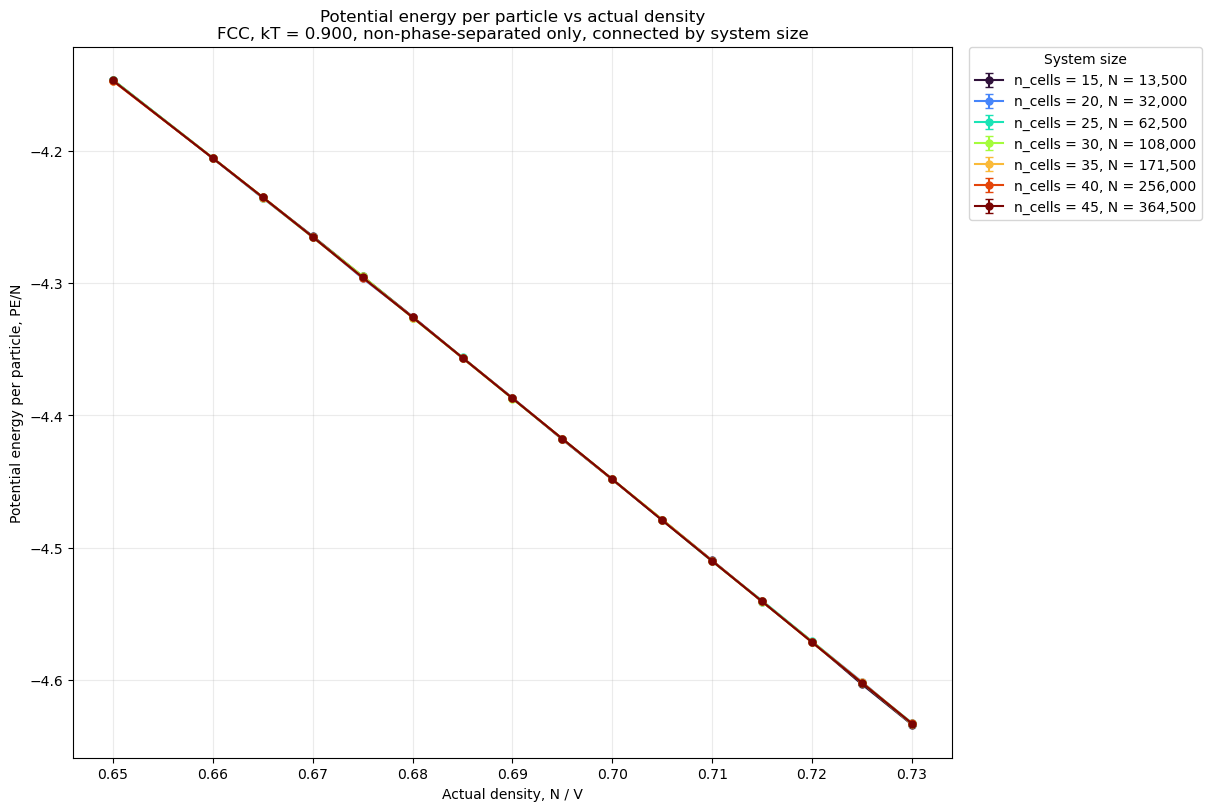

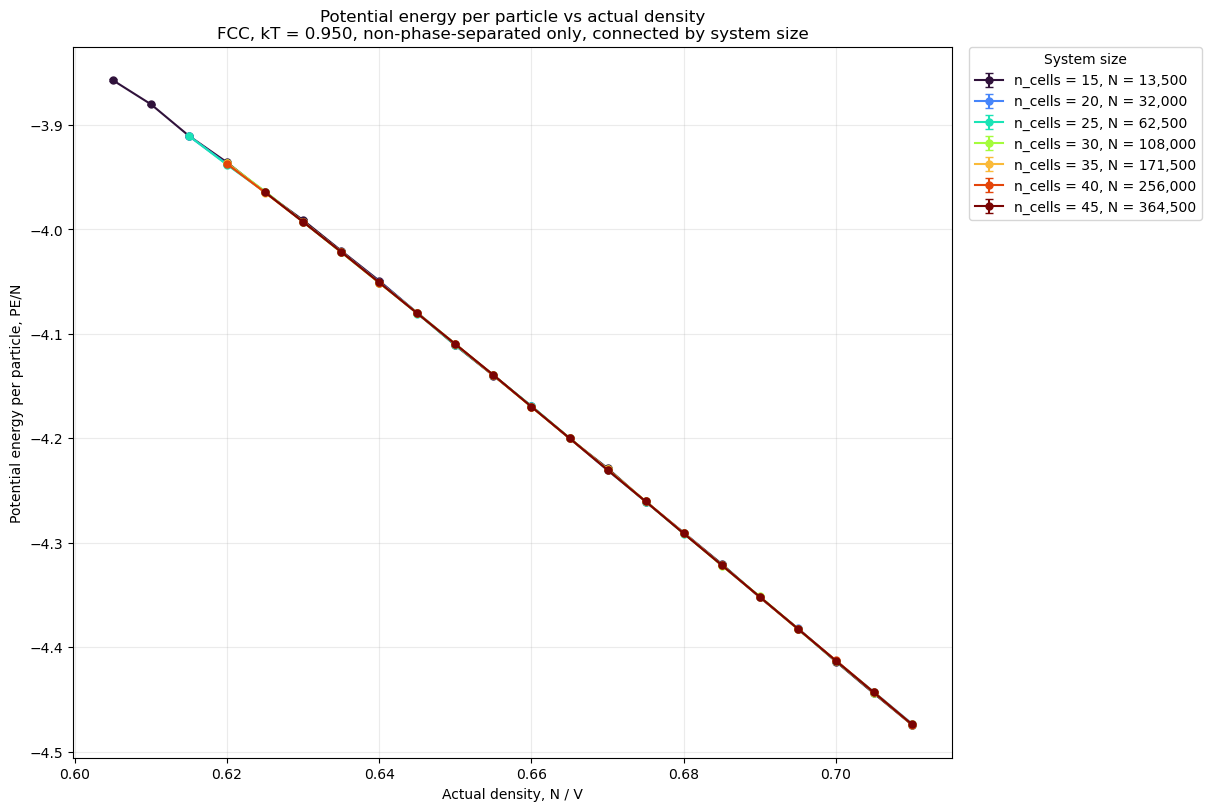

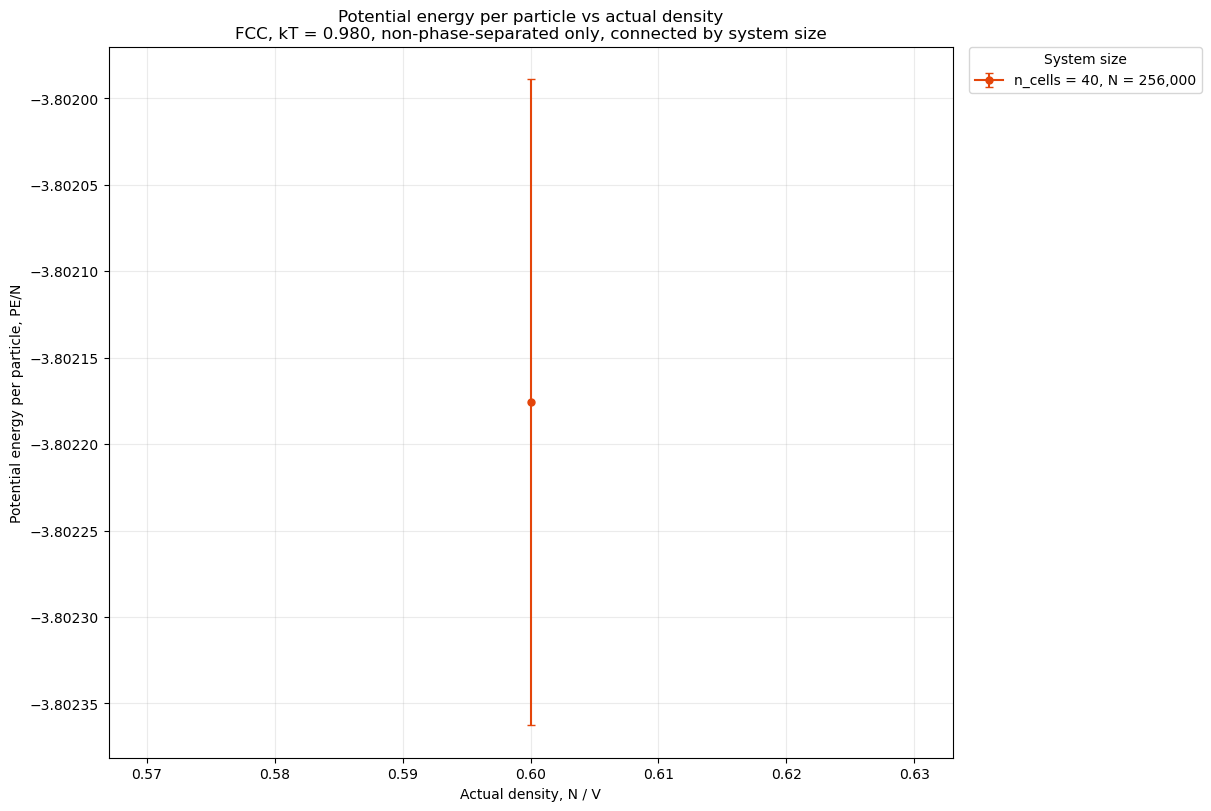

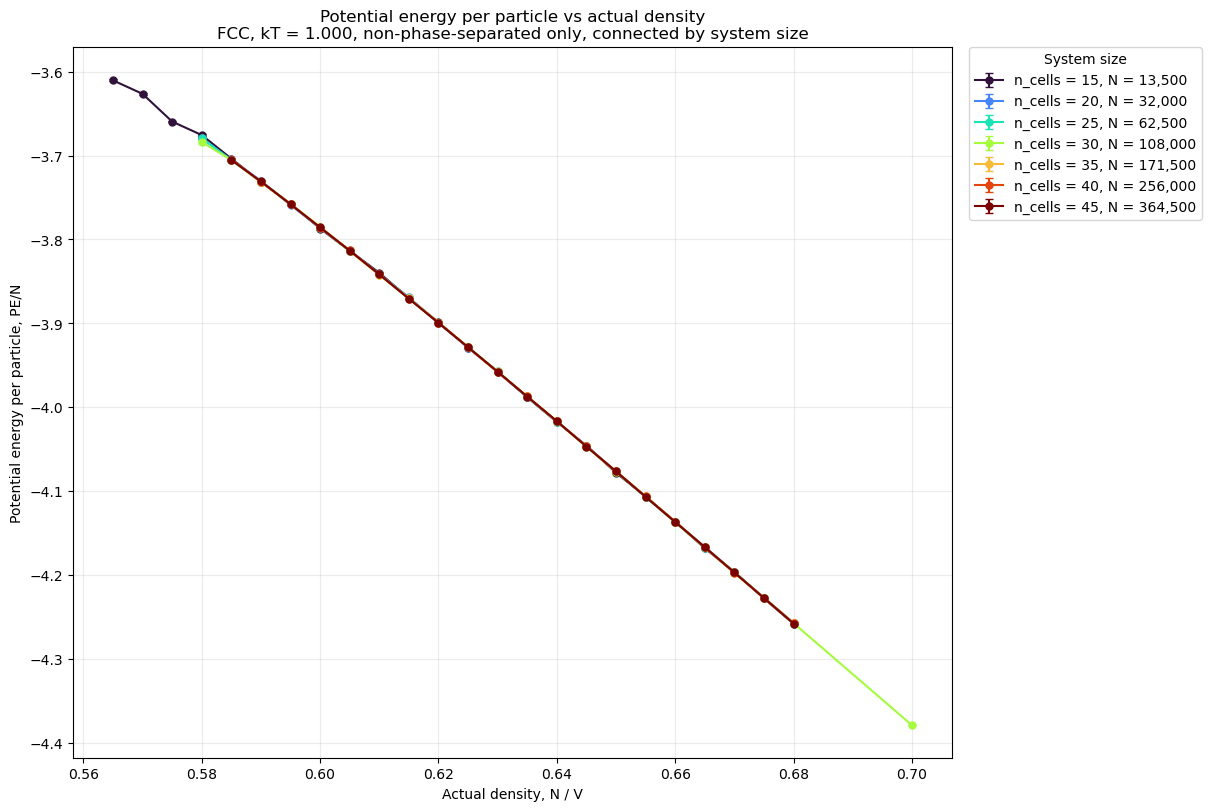

,Run_ID,N_Cells,N_Particles,Therm_kT,Actual_Density,PE_Per_Particle_Mean,PE_Per_Particle_SEM,Nsteps,Therm_Seed,Clone_Run_ID
0,20260917190822,15,13500,0.9,0.650,-4.146558,0.000661,200000,1,None
1,20260917191018,15,13500,0.9,0.660,-4.205507,0.000695,200000,1,None
2,20260917212450,15,13500,0.9,0.665,-4.235116,0.000708,200000,1,None
3,20260917190939,15,13500,0.9,0.670,-4.264491,0.000633,200000,1,None
4,20260917212412,15,13500,0.9,0.675,-4.294923,0.000644,200000,1,None
...,...,...,...,...,...,...,...,...,...,...
393,20260918015417,45,364500,1.0,0.660,-4.136658,0.000132,200000,1,None
394,20260918232346,45,364500,1.0,0.665,-4.166541,0.000141,200000,1,None
395,20260918015941,45,364500,1.0,0.670,-4.196808,0.000152,200000,1,None
396,20260918232914,45,364500,1.0,0.675,-4.227253,0.000130,200000,1,None


In [4]:
# ============================================================
# Plot PE/N versus density:
# one figure per temperature, one color per N_Cells
# ============================================================

required_pe_columns = [
    "PE_Per_Particle_Mean",
    "PE_Per_Particle_SEM",
]

missing_pe_columns = [
    column
    for column in required_pe_columns
    if column not in eos_states.columns
]

if missing_pe_columns:
    raise KeyError(
        f"Thermalization query is missing PE/N columns: "
        f"{missing_pe_columns}"
    )


# Work with a separate copy so the pressure data remains unchanged.
pe_states = eos_states.copy()

for column in required_pe_columns:
    pe_states[column] = pd.to_numeric(
        pe_states[column],
        errors="coerce",
    )

pe_states = pe_states.loc[
    np.isfinite(pe_states["Actual_Density"])
    & np.isfinite(pe_states["PE_Per_Particle_Mean"])
].copy()

if pe_states.empty:
    raise RuntimeError(
        "The matching thermalization states contain no finite "
        "PE/N results."
    )


# Optional PE/N-axis limits. Use None for automatic limits.
pe_per_particle_limits = None


# ============================================================
# Make the figures
# ============================================================

pe_figures = {}

for temperature, temperature_data in pe_states.groupby(
    "Therm_kT",
    sort=True,
):
    figure, axis = plt.subplots(
        figsize=figure_size,
        constrained_layout=True,
    )

    for n_cells, size_data in temperature_data.groupby(
        "N_Cells",
        sort=True,
    ):
        size_data = (
            size_data
            .sort_values("Actual_Density")
            .reset_index(drop=True)
        )

        n_cells = int(n_cells)
        n_particles = 4 * n_cells**3
        color = n_cells_colors[n_cells]

        pe_sem = size_data[
            "PE_Per_Particle_SEM"
        ].to_numpy(dtype=float)

        # Replace unavailable uncertainties with zero for plotting only.
        pe_sem = np.where(
            np.isfinite(pe_sem),
            pe_sem,
            0.0,
        )

        axis.errorbar(
            size_data["Actual_Density"],
            size_data["PE_Per_Particle_Mean"],
            yerr=pe_sem,
            marker="o",
            markersize=marker_size,
            linewidth=line_width,
            capsize=errorbar_capsize,
            color=color,
            label=(
                f"n_cells = {n_cells}, "
                f"N = {n_particles:,}"
            ),
        )

    axis.set_title(
        "Potential energy per particle vs actual density\n"
        f"FCC, kT = {float(temperature):.3f}, "
        "non-phase-separated only, connected by system size"
    )

    axis.set_xlabel("Actual density, N / V")
    axis.set_ylabel("Potential energy per particle, PE/N")
    axis.grid(True, alpha=0.25)

    if density_limits is not None:
        axis.set_xlim(*density_limits)

    if pe_per_particle_limits is not None:
        axis.set_ylim(*pe_per_particle_limits)

    axis.legend(
        title="System size",
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        borderaxespad=0.0,
    )

    pe_figures[float(temperature)] = figure
    plt.show()


# ============================================================
# Display the exact points used in the PE/N plots
# ============================================================

pe_plot_points = pe_states[
    [
        "Run_ID",
        "N_Cells",
        "N_Particles",
        "Therm_kT",
        "Actual_Density",
        "PE_Per_Particle_Mean",
        "PE_Per_Particle_SEM",
        "Nsteps",
        "Therm_Seed",
        "Clone_Run_ID",
    ]
].copy()

display(pe_plot_points)